# `E_macro` — what each pillar is actually worth

**Status report, 13 August 2026**, covering two weeks of work. Roughly 30 minutes;
sections 1–6 are the talk, the appendix is so the notebook stands on its own
afterwards.

Every validation before these two weeks asked whether the six pillars agree with
each other. These two weeks ask what each one is worth.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import json
import subprocess
import textwrap
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Walk up to the repo root rather than assuming a directory name: this notebook
# is executed from analysis-output/ when it is the deliverable and from build/
# when it is staged for the HTML export, and both have to resolve the same way.
REPO = Path.cwd()
while not (REPO / "analysis-output").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
OUTPUTS, ANALYSIS = REPO / "outputs", REPO / "analysis-output"
XSRC = ANALYSIS / "cross-source"

# ---- artifacts -----------------------------------------------------------
ext = json.loads((XSRC / "external_target_stats.json").read_text())
blk = json.loads((XSRC / "pillar_block_marginal_stats.json").read_text())
gst = json.loads((XSRC / "grain_effect_stats.json").read_text())
scope = json.loads((ANALYSIS / "source-a" / "source_a_section_scope_stats.json").read_text())
embed = json.loads((ANALYSIS / "source-a" / "source_a_tiered_embedding_stats.json").read_text())
etier = json.loads((ANALYSIS / "source-e" / "source_e_tier_stats.json").read_text())

placebo = pd.read_csv(OUTPUTS / "external_target_drop_one_placebo.csv")
decile = pd.read_csv(OUTPUTS / "external_target_by_decile.csv")
vintages = pd.read_csv(OUTPUTS / "pillar_vintages.csv")

PILLARS = ["A", "B", "C", "D", "E", "F"]
PILLAR_NAME = {
    "A": "A · Place identity",
    "B": "B · Industrial core",
    "C": "C · Economic velocity",
    "D": "D · Trade logistics",
    "E": "E · Capital flow",
    "F": "F · Structural resilience",
}
TARGET_LABEL = {
    "broadband_rate": "Broadband adoption",
    "median_household_income": "Median household income",
    "median_age": "Median age",
    "median_home_value": "Median home value",
    "mean_commute_minutes": "Mean commute",
}
TARGET_ORDER = list(TARGET_LABEL)

# ---- palette -------------------------------------------------------------
# Same validated reference palette as the brief this notebook replaces.
# Categorical slots are fixed, never cycled: a series keeps its slot when
# others are added or removed.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLUE, AQUA, CRITICAL = SERIES[0], SERIES[2], "#d03b3b"
SURFACE, INK, INK2 = "#fcfcfb", "#0b0b0b", "#52514e"
MUTED, GRID = "#d5d4d0", "#ecebe6"
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 11,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 110,
})


def style(ax, title, subtitle="", grid_axis="y", legend=False):
    """House chart style, sized for a projector rather than a laptop.

    Matplotlib rather than plotly: plotly's mimetype output needs a JupyterLab
    extension to render, and silently produces blank space when that extension
    is missing. Matplotlib emits a PNG that every notebook client and the HTML
    export display without any additional machinery.

    Chrome is recessive — no spines, a hairline grid on one axis only, tick
    labels a step down from the body — so the bars carry the figure.
    """
    ax.set_axisbelow(True)
    ax.grid(axis=grid_axis, color=GRID, linewidth=1)
    ax.grid(axis="x" if grid_axis == "y" else "y", visible=False)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0, colors=INK2, labelsize=10.5)

    # Subtitles run long; wrapping by hand keeps them off the plot area, which
    # matplotlib will not do on its own. Both title and subtitle are positioned
    # in points offset from the axes edge rather than in axes fractions -- mixing
    # the two units makes them overlap, and by how much depends on figure height.
    sub = textwrap.fill(subtitle, 104) if subtitle else ""
    n_lines = sub.count("\n") + 1 if subtitle else 0
    line_h = 14.5
    ax.set_title(title, loc="left", fontsize=15, fontweight="bold", color=INK,
                 pad=(8 + n_lines * line_h + 8) if subtitle else 12)
    if subtitle:
        ax.annotate(sub, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 8), textcoords="offset points",
                    va="bottom", ha="left", fontsize=10, color=INK2,
                    linespacing=1.45)
    if legend:
        ax.legend(loc="upper left", bbox_to_anchor=(0, -0.13), ncol=2,
                  frameon=False, fontsize=10.5, labelcolor=INK2,
                  handlelength=1.4, columnspacing=1.8)
    return ax


def label_bars(ax, xs, ys, fmt="{:+.4f}", size=10.5, pad=0.012, horizontal=False):
    """Write each bar's value just past its end, outside the bar.

    `pad` is a fraction of the axis span, so labels sit the same visual distance
    from the bar regardless of the units on the axis.
    """
    lo, hi = (ax.get_xlim() if horizontal else ax.get_ylim())
    off = (hi - lo) * pad
    for x, y in zip(xs, ys):
        if horizontal:
            ax.text(y + (off if y >= 0 else -off), x, fmt.format(y),
                    va="center", ha="left" if y >= 0 else "right",
                    fontsize=size, color=INK)
        else:
            ax.text(x, y + (off if y >= 0 else -off), fmt.format(y),
                    ha="center", va="bottom" if y >= 0 else "top",
                    fontsize=size, color=INK)


# ---- provenance ----------------------------------------------------------
sha = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()
# Tracked modifications only, and notebooks excluded: this notebook lives under
# analysis-output/ and its own execution would otherwise register as drift in
# the artifacts it is reporting on.
dirty = subprocess.run(
    ["git", "-C", str(REPO), "status", "--porcelain", "--untracked-files=no",
     "--", "outputs", "analysis-output", ":(exclude)*.ipynb"],
    capture_output=True, text=True,
).stdout.strip()

print(f"Run stamp · {date.today():%d %B %Y} · commit {sha}")
print("Every figure below is computed from outputs/ and analysis-output/,")
print("regenerated from data/*.parquet by the six analysis scripts on 13 Aug 2026.")
print("Regenerated artifacts vs. committed: "
      f"{'IDENTICAL — no drift' if not dirty else 'DIFFER — see git diff'}")
print()
print(f"Evidence base · {ext['n_targets']} external targets · {ext['fold_strategy']} "
      f"· {blk['n_null_reps']} null reps · seed {ext['random_seed']}")

Run stamp · 17 August 2026 · commit 5c773a8
Every figure below is computed from outputs/ and analysis-output/,
regenerated from data/*.parquet by the six analysis scripts on 13 Aug 2026.
Regenerated artifacts vs. committed: IDENTICAL — no drift

Evidence base · 5 external targets · GroupKFold on state_fips (spatially blocked) · 49 null reps · seed 42


---

## 1. Getting out of the circle

**Every validation before these two weeks was pillar against pillar** — predict one
federal source's features from the other five. That measures whether six agencies
agree with each other; it cannot say whether any of them is *useful*. The bias even
runs the wrong way, penalising a source precisely for agreeing with the others. And
a real label is not available: the project is scoped to public data only, which is
a boundary, not an oversight.

**The substitute is five public outcomes no pillar measures** — ACS broadband
adoption, median household income, median age, median home value, mean commute.
None is constructed from any pillar's inputs.

**The design is built around one specific objection.** The consuming team joins on
DMA with millions of impressions per market, so it can estimate a geographic fixed
effect essentially for free — which makes any static geo-keyed feature look
redundant. A fixed effect has exactly one weakness: **no parameter for a place it
has never seen.** So the test holds out **whole states** and compares against a
model that knows only county size. That seam is the whole design, and it is what
section 4 returns to.

**The same seam then goes one level down.** Withhold a single pillar's block from a
model that already holds county size *and the other five*, and measure the R² it
loses. Three decisions make the result survivable: every pillar takes the same test;
restatements are ablated, so no pillar is paid for repeating a neighbour; and the
noise floor is measured by shuffling each block rather than assumed.

The pass/fail rule was written down before the numbers arrived and was not
renegotiated afterwards — full text in appendix A2.

---

## 2. The result, and the discount applied to it

The raw number is **+0.212**. The number reported is **+0.190**. The gap is
deliberate, and it is the part worth showing first — it is the kind of thing that
normally gets caught in review rather than found by the author.

**Two pillar columns don't so much predict their target as restate it:**

- **`wage_per_return_thousands`** (IRS) is average wage income per tax return —
  very close to a definition of median household income. Removing it drops that
  outcome's gain from +0.247 to **+0.154**. One column was carrying **38%** of the
  apparent result.
- **`retirement_destination`** (USDA) flags counties with heavy in-migration of
  people aged 60+, which restates age structure. Smaller effect: +0.256 → +0.239.

Both are dropped from their own target's run and kept everywhere else. **The
headline is the discounted number.**

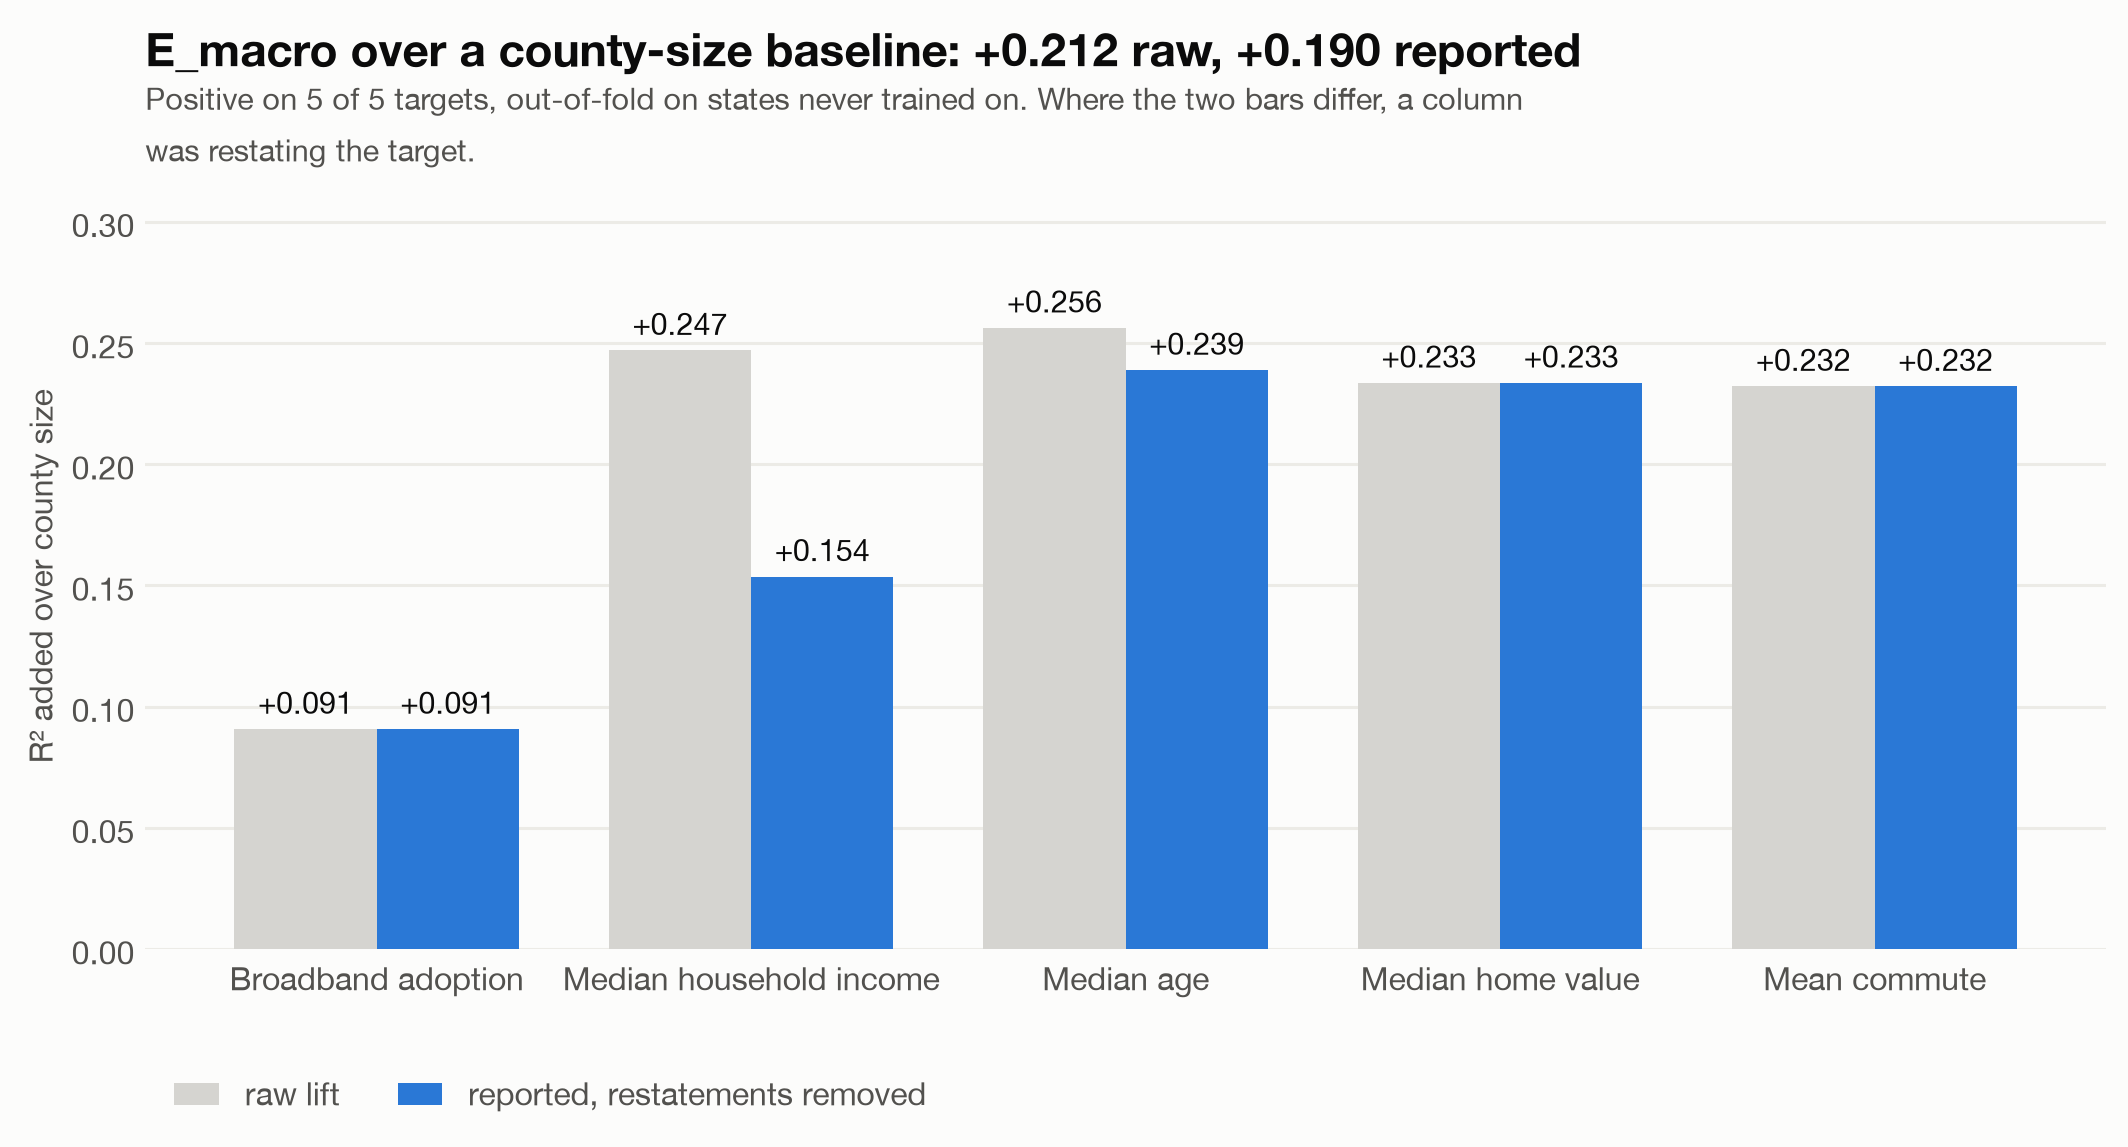

In [2]:
by_t = ext["by_target"]
labels = [TARGET_LABEL[t] for t in TARGET_ORDER]
raw = [by_t[t]["lift_over_size"] for t in TARGET_ORDER]
rep = [by_t[t]["lift_over_size_ablated"] for t in TARGET_ORDER]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.bar(x - w / 2, raw, w, color=MUTED, label="raw lift")
ax.bar(x + w / 2, rep, w, color=BLUE, label="reported, restatements removed")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(raw) * 1.2)
label_bars(ax, x - w / 2, raw, "+{:.3f}", size=10)
label_bars(ax, x + w / 2, rep, "+{:.3f}", size=10)
ax.set_ylabel("R² added over county size", fontsize=10.5, color=INK2)
style(ax,
      f"E_macro over a county-size baseline: {ext['mean_lift_over_size']:+.3f} raw, "
      f"{ext['mean_lift_over_size_ablated']:+.3f} reported",
      f"Positive on {ext['targets_with_positive_lift']} of {ext['n_targets']} targets, "
      "out-of-fold on states never trained on. Where the two bars differ, a column "
      "was restating the target.",
      legend=True)
plt.show()

**And within that result, what each pillar is worth.** Read the figure as: how much
predictive power the matrix loses when this pillar is taken out of it. The grey
band is the noise floor — the most any *shuffled* version of a block managed.

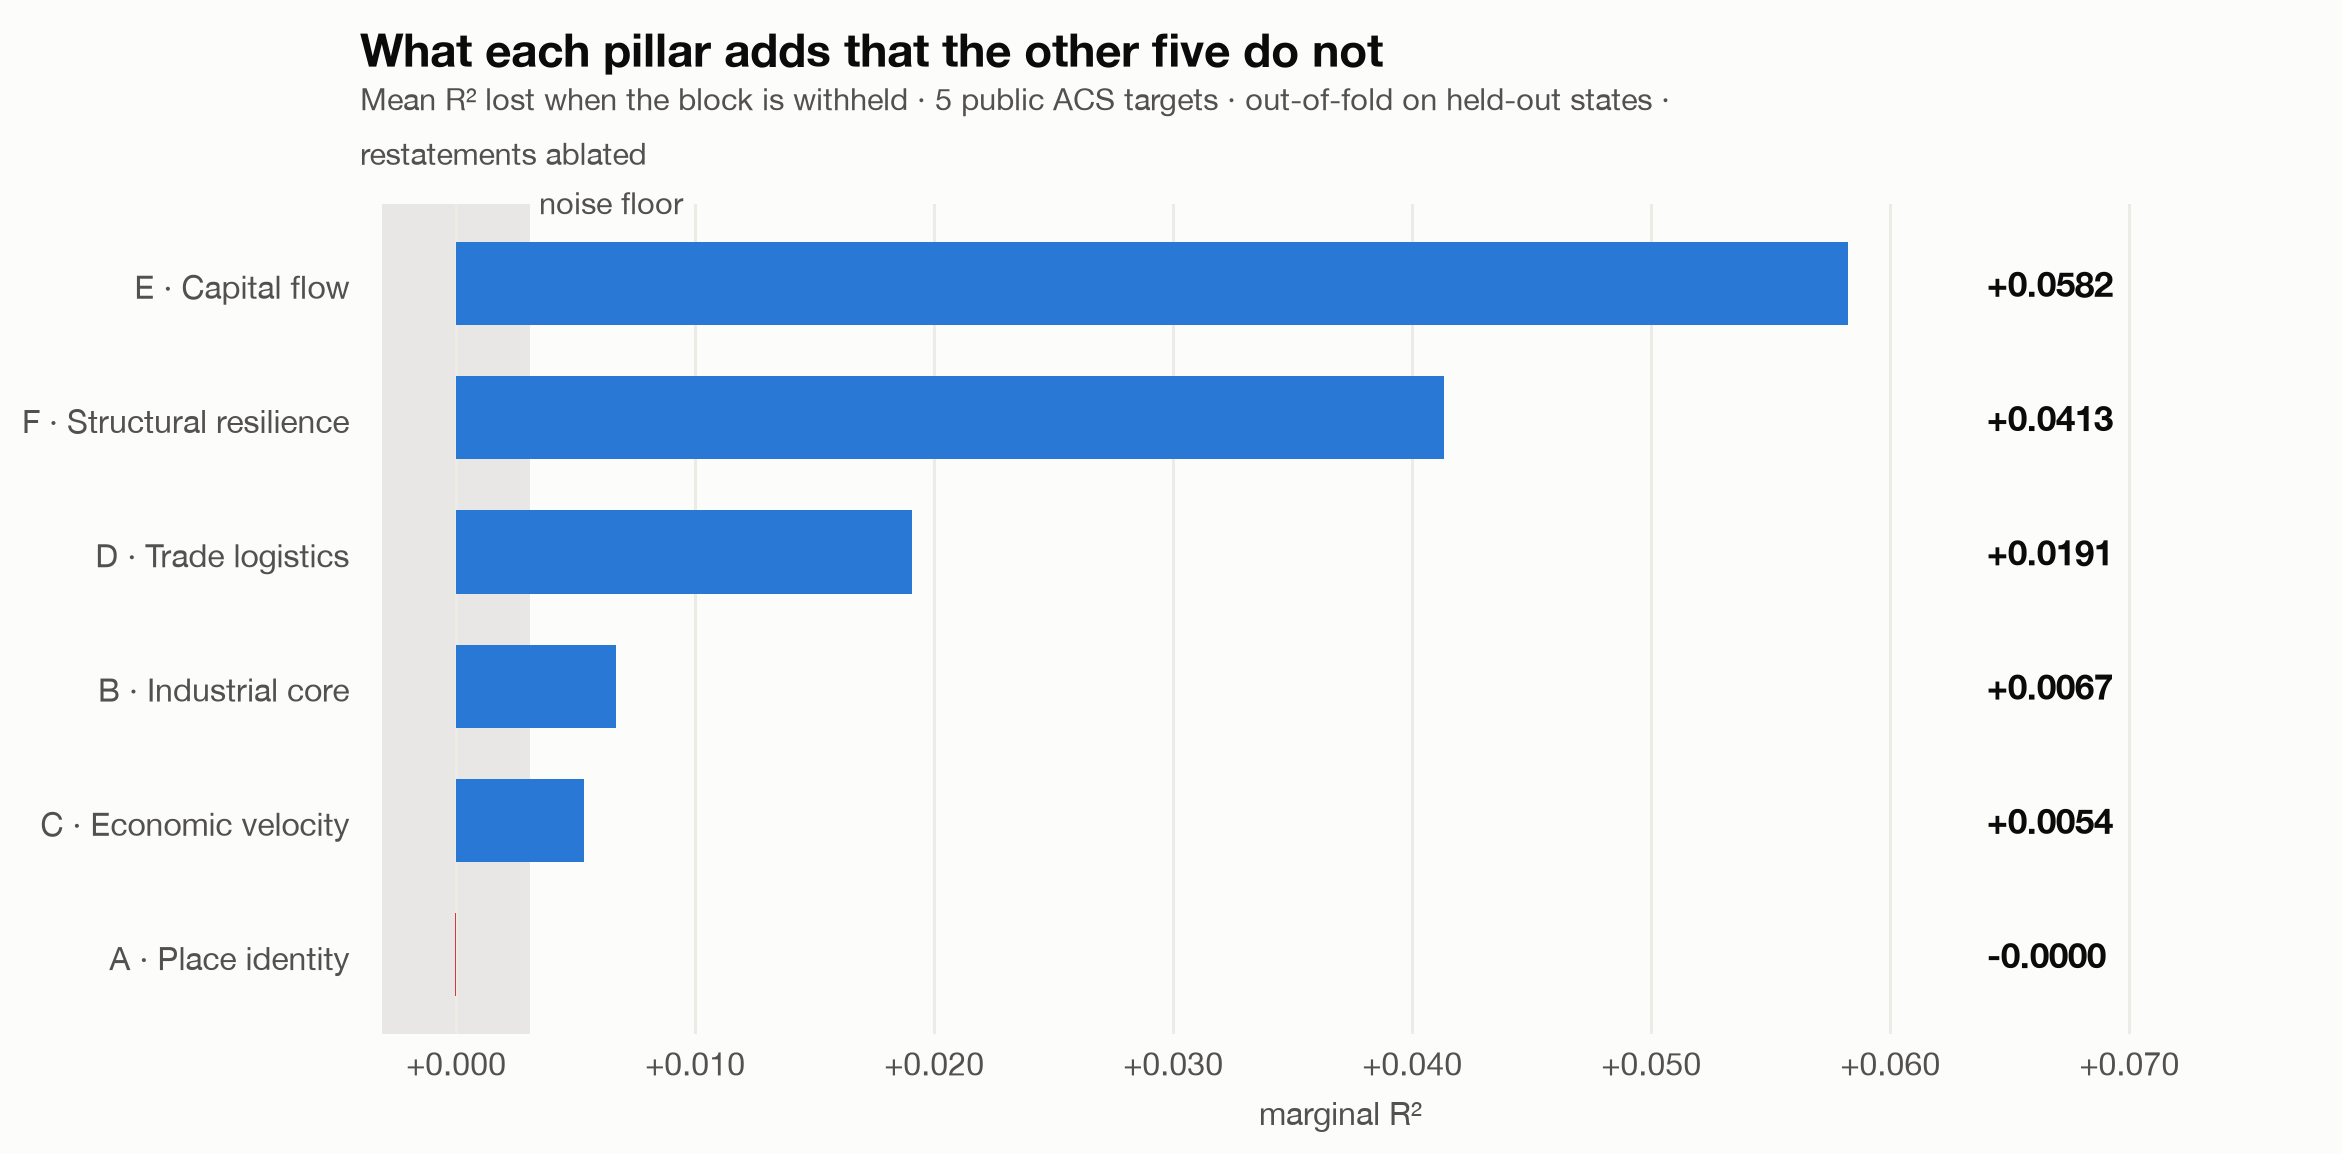

In [3]:
floor = ext["drop_one_noise_floor"]
# Contribution comes from drop_one, NOT from the noise-floor dict: the latter
# carries F's `_no_ametro` robustness variant (+0.0410, scored against a
# different reference model), and quoting it here would silently understate the
# headline figure the findings report and docs both use (+0.0413).
rows = [{"pillar": p,
         "label": PILLAR_NAME[p],
         "contribution": ext["drop_one"][f"size_emacro_drop_{p}"]["mean_contribution_ablated"],
         "floor": floor[p]["max_placebo"],
         "above": floor[p]["n_targets_above_floor"],
         "positive": ext["drop_one"][f"size_emacro_drop_{p}"]["n_positive_ablated"]}
        for p in PILLARS]
worth = pd.DataFrame(rows).sort_values("contribution")

band = float(worth["floor"].max())
hi = float(worth["contribution"].max())
lo = min(-band, float(worth["contribution"].min()))

y = np.arange(len(worth))
fig, ax = plt.subplots(figsize=(11.5, 4.9))
ax.barh(y, worth["contribution"], height=0.62,
        color=[CRITICAL if v <= 0 else BLUE for v in worth["contribution"]])
ax.set_yticks(y)
ax.set_yticklabels(worth["label"])
ax.set_xlim(lo * 1.3, hi * 1.34)

# The noise floor is a property of the measurement, not a series — a shaded band
# rather than a legend entry, so it reads as the bar to clear.
ax.axvspan(-band, band, color=MUTED, alpha=0.5, linewidth=0, zorder=0)
ax.text(band, len(worth) - 0.4, " noise floor", fontsize=10, color=INK2,
        va="center", ha="left")

# Values sit in a fixed right-hand column rather than just past each bar end.
# Tracking the bar end puts Source A's near-zero value on top of its own category
# label and pushes Source E's off the canvas.
for i, v in enumerate(worth["contribution"]):
    ax.text(hi * 1.1, i, f"{v:+.4f}", va="center", ha="left",
            fontsize=11.5, fontweight="bold", color=INK)

ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_xlabel("marginal R²", fontsize=10.5, color=INK2)
style(ax,
      "What each pillar adds that the other five do not",
      "Mean R² lost when the block is withheld · 5 public ACS targets · "
      "out-of-fold on held-out states · restatements ablated",
      grid_axis="x")
plt.show()

In [4]:
table = worth.sort_values("contribution", ascending=False).copy()
table["Marginal R²"] = table["contribution"].map(lambda v: f"{v:+.4f}")
table["Positive on"] = table["positive"].map(lambda v: f"{v} of 5")
table["Above noise floor on"] = table["above"].map(lambda v: f"{v} of 5")
display(table[["label", "Marginal R²", "Positive on", "Above noise floor on"]]
        .rename(columns={"label": "Pillar"})
        .set_index("Pillar"))

,Marginal R²,Positive on,Above noise floor on
Pillar,,,
E · Capital flow,+0.0582,5 of 5,5 of 5
F · Structural resilience,+0.0413,5 of 5,5 of 5
D · Trade logistics,+0.0191,5 of 5,5 of 5
B · Industrial core,+0.0067,3 of 5,4 of 5
C · Economic velocity,+0.0054,5 of 5,4 of 5
A · Place identity,-0.0000,2 of 5,2 of 5


**The caveat travels with the headline, not after it.** These five targets are
**public proxies, not the consuming team's label** — which is unobtainable under
the scope this project was given. Everything above is an argument by analogy. It is
the strongest non-circular evidence this project can produce, and it is still an
analogy. Appendix A1 takes that objection seriously rather than footnoting it.

---

## 3. Two pillars moved

### Source F — kept, on a test it could have failed

F was flagged as the pillar falling short, for a real reason: its one strong
relationship in the whole 15-pair sweep was against Source D freight tonnage,
**r = 0.495 raw — the largest raw effect anywhere in that sweep — collapsing to
r = −0.057 once county size is controlled.** The apparent link was population
riding along in both variables.

The resolution on file was to keep F and reclassify it as a "structural anchor,"
justified by what county typology definitionally *is* rather than by measured
performance. That was a rationalisation, and it was withdrawn.

**What replaced it.** The status doc named the fairer test itself — does F explain
residual variance once B/C/D/E are already in the model — and that test was run. F
contributes **+0.0413**, second of the six, positive on 5 of 5 targets and above
the noise floor on 5 of 5, where the largest contribution any shuffled block
produced anywhere was +0.0031.

**Both facts travel together.** F still fails the pairwise hub test. It passed the
residual-variance test that was pre-registered for it. The first instrument was
wrong for a categorical structural variable, and that was said before the numbers
existed, not after.

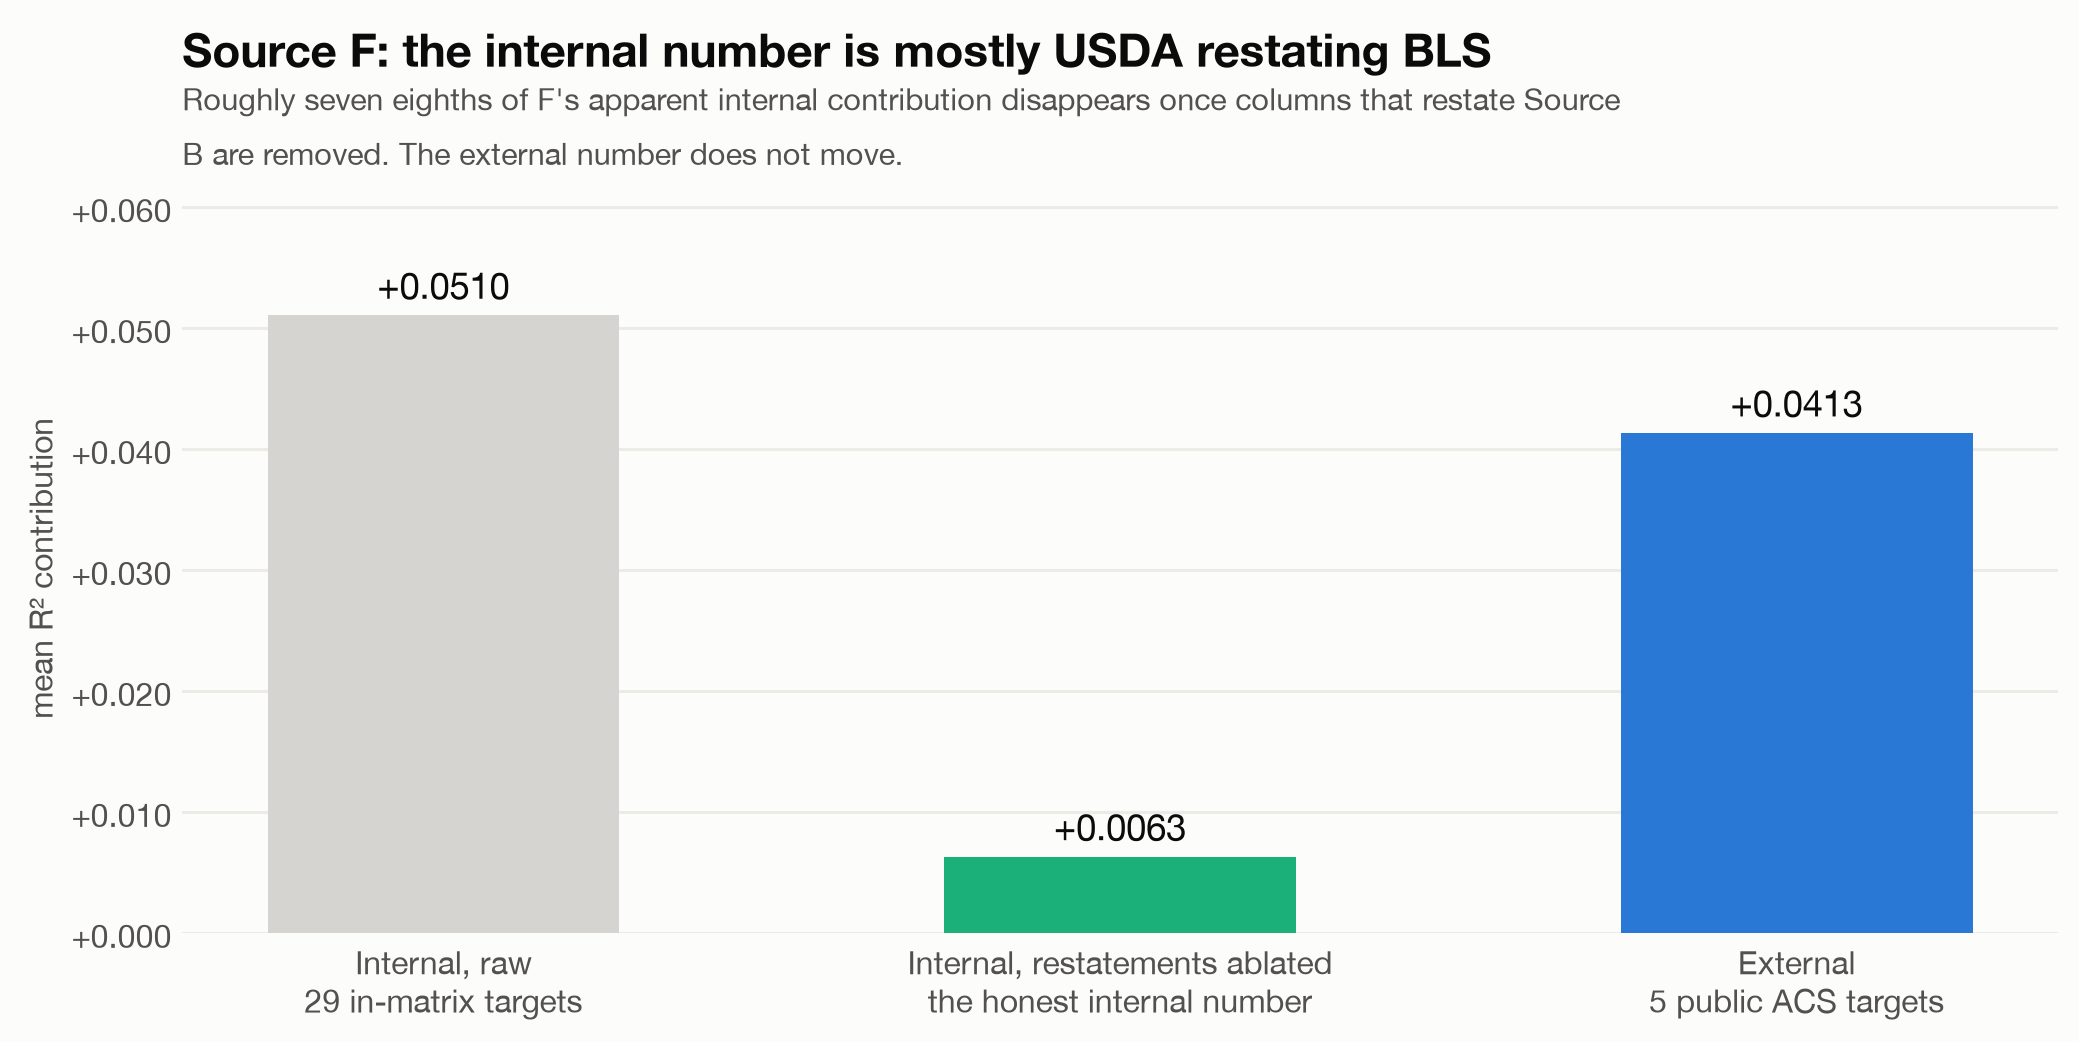

In [5]:
fb = blk["by_block"]["F"]
# Headline external figure, not the `_no_ametro` robustness variant — see the
# comment on the section 2 figure.
f_ext = ext["drop_one"]["size_emacro_drop_F"]["mean_contribution_ablated"]
# NOTE: newlines in these labels are escaped because this cell's source is a
# non-raw triple-quoted string in the builder — an unescaped \n would be
# consumed at build time and split the string literal.
bars = [
    ("Internal, raw\n29 in-matrix targets", fb["mean_lift"], MUTED),
    ("Internal, restatements ablated\nthe honest internal number",
     fb["mean_lift_ablated"], AQUA),
    ("External\n5 public ACS targets", f_ext, BLUE),
]
x = np.arange(len(bars))
vals = [b[1] for b in bars]
fig, ax = plt.subplots(figsize=(11, 4.3))
ax.bar(x, vals, 0.52, color=[b[2] for b in bars])
ax.set_xticks(x)
ax.set_xticklabels([b[0] for b in bars])
ax.set_ylim(0, max(vals) * 1.18)
label_bars(ax, x, vals, size=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
ax.set_ylabel("mean R² contribution", fontsize=10.5, color=INK2)
style(ax,
      "Source F: the internal number is mostly USDA restating BLS",
      "Roughly seven eighths of F's apparent internal contribution disappears once "
      "columns that restate Source B are removed. The external number does not move.")
plt.show()

The middle bar is the one to sit with. **Seven eighths of F's apparent internal
contribution is USDA restating industry composition BLS already measures.** That
redundancy is real inside the six-pillar system, and it does not bind against
outcomes outside it — the same ablation moves F's external figure by 0.0003. Which
is exactly why the external arm is the one the verdict rests on.

### Source A — the uncomfortable finding

Source A is the pillar this project marked **"Good shape. Done."** Its embedding was
cut on evidence, its 29 typed columns were validated, its schema was frozen first.
It contributes **−0.0000**.

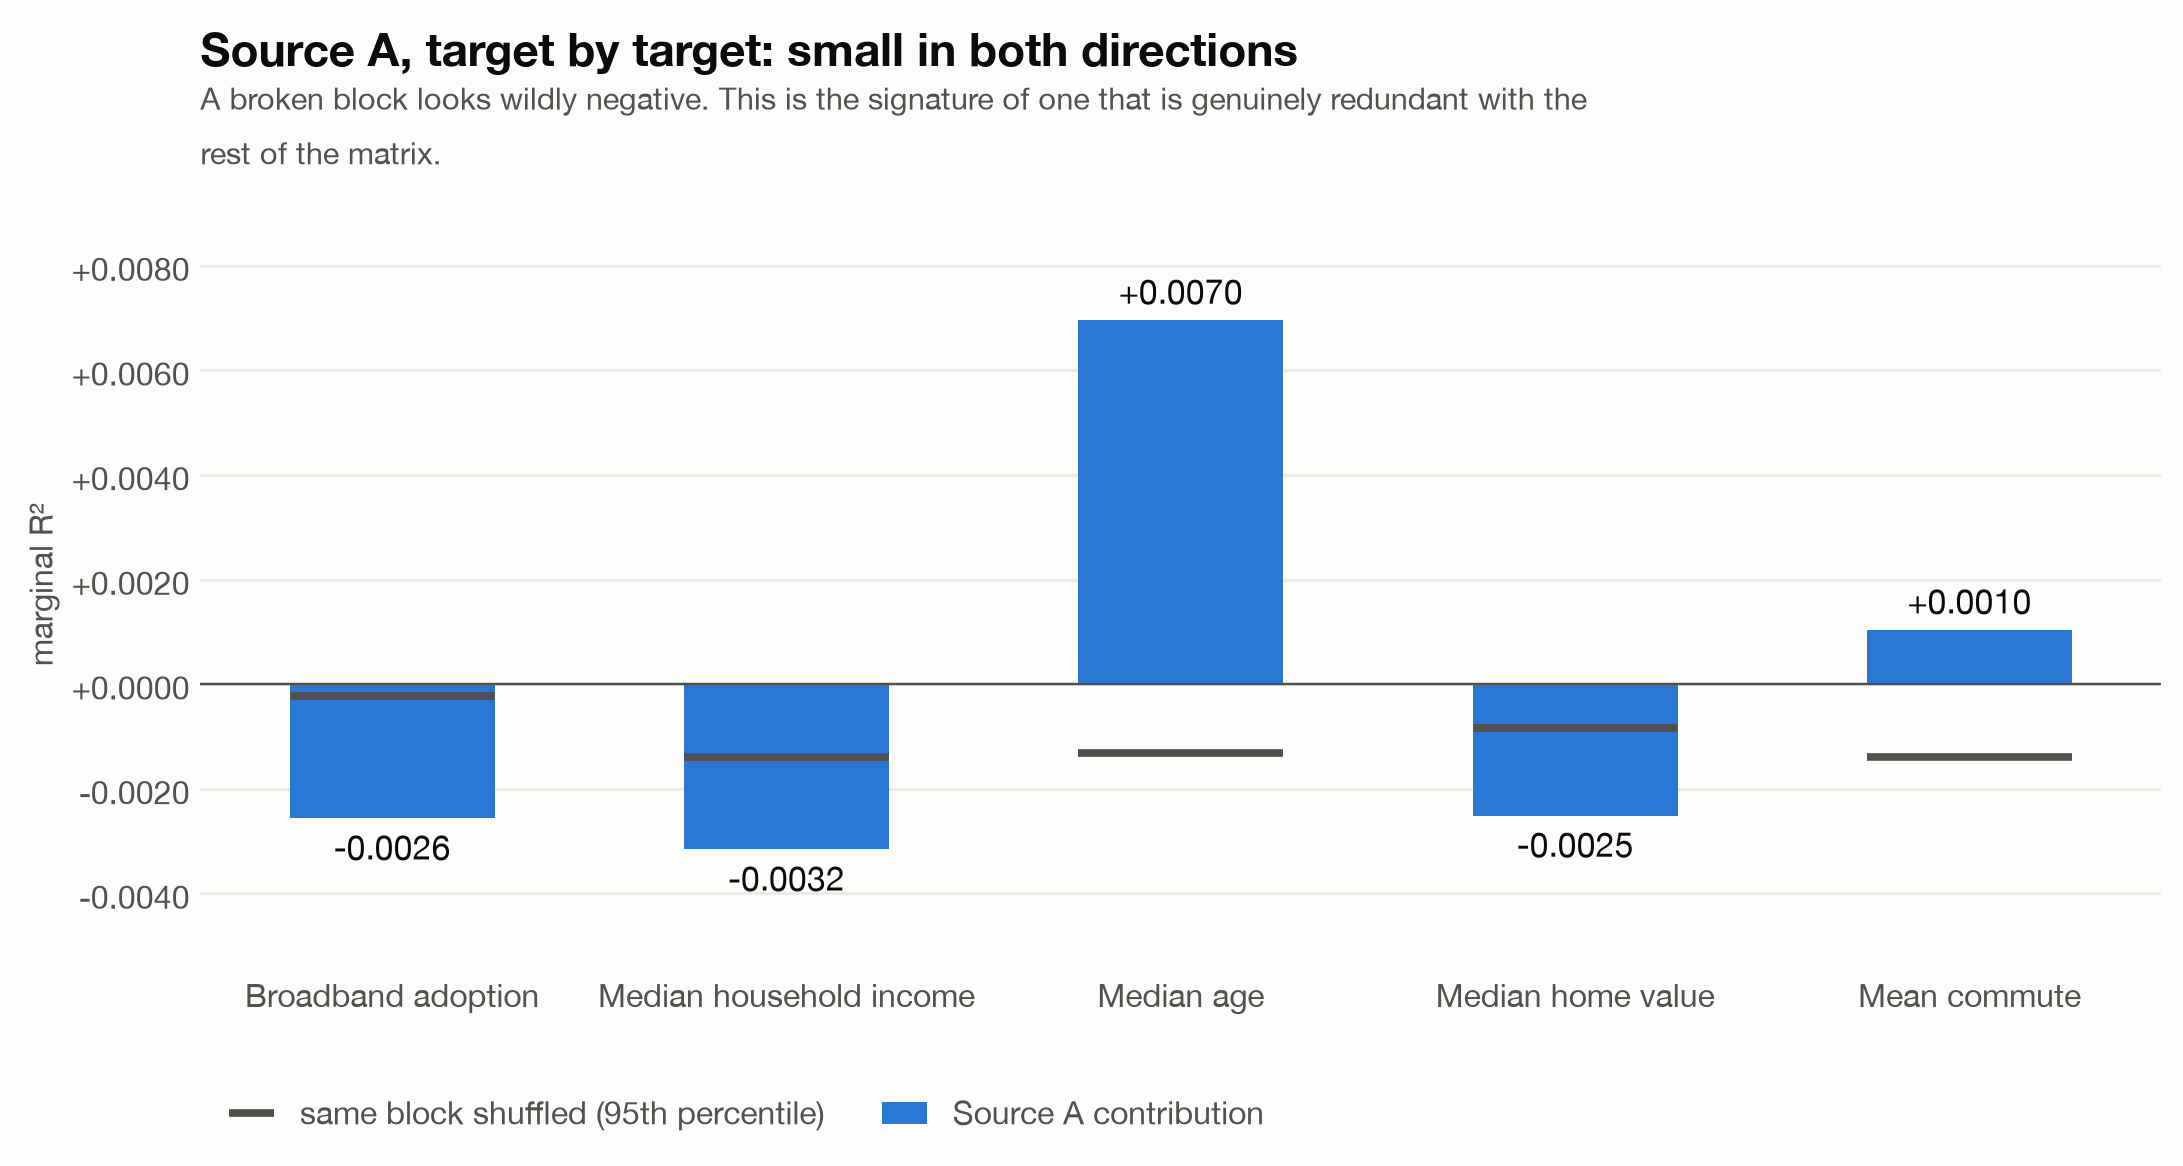

In [6]:
a_stats = ext["drop_one"]["size_emacro_drop_A"]
a_pl = placebo[placebo["pillar"] == "A"].set_index("target")
labels = [TARGET_LABEL[t] for t in TARGET_ORDER]
vals = [a_stats["by_target"][t] for t in TARGET_ORDER]
band = [float(a_pl.loc[t, "placebo_p95"]) if t in a_pl.index else 0.0 for t in TARGET_ORDER]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11.5, 4.5))
# One colour, not red-for-negative: sign is already carried by position against
# the zero line, and a two-colour split would dramatise numbers whose whole point
# is that they are small.
ax.bar(x, vals, 0.52, color=BLUE, label="Source A contribution")
ax.hlines(band, x - 0.26, x + 0.26, color=INK2, linewidth=2.5,
          label="same block shuffled (95th percentile)")
ax.axhline(0, color=INK2, linewidth=0.8, zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(labels)
span = max(vals + band) - min(vals + band)
ax.set_ylim(min(vals + band) - span * 0.22, max(vals + band) + span * 0.22)
label_bars(ax, x, vals, size=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.4f}"))
ax.set_ylabel("marginal R²", fontsize=10.5, color=INK2)
style(ax,
      "Source A, target by target: small in both directions",
      "A broken block looks wildly negative. This is the signature of one that is "
      "genuinely redundant with the rest of the matrix.",
      legend=True)
plt.show()

**Not a harness failure.** The same code path produces +0.0582 for E and +0.0413
for F, the placebo distributions behave, and A's per-target numbers are small in
*both* directions rather than wildly negative.

**Not a contradiction of the evidence on file either.** A's typed block was
justified on a marginal lift of **+0.0010** over a baseline holding every other
pillar — a real effect, at p = 0.010 with power 0.92, and a tiny one. A
contribution indistinguishable from zero against five external outcomes is what
that effect size predicts. A is also the only block negative in **both** arms:
−0.0031 internally, −0.0000 externally.

**What it means.** Applied consistently, the operating principle that every pillar
earns its slot on evidence now points at Source A rather than Source F. That is
uncomfortable and it is the honest reading.

### The open question this puts to the room

> **Does Source A ship?** The recommendation is to cut it — *unless* the consuming
> team's real target rewards what A encodes.
>
> Three arguments defend keeping it, and only one survives. *A is nearly free* is
> about cost, not worth. *Redundancy is insurance for a county missing another
> pillar* is plausible and untested. But *the ACS targets are a poor match for what
> A encodes* is live: A carries named industries, universities, ports and protected
> land, and whether that is worth anything depends on whether the downstream target
> is closer to "who lives here" — where A adds nothing — or "what happens here
> economically."
>
> Only the commissioning side can answer that, which is why this is raised rather
> than decided.

---

## 4. Three honest limits

**1. The fixed-effect objection from section 1 is still unanswered.** Holding out
states shows `E_macro` beats a size baseline on places it has never seen; it does
not show it beats a DMA dummy on places the consumer sees constantly. What the
grain question costs in each direction:

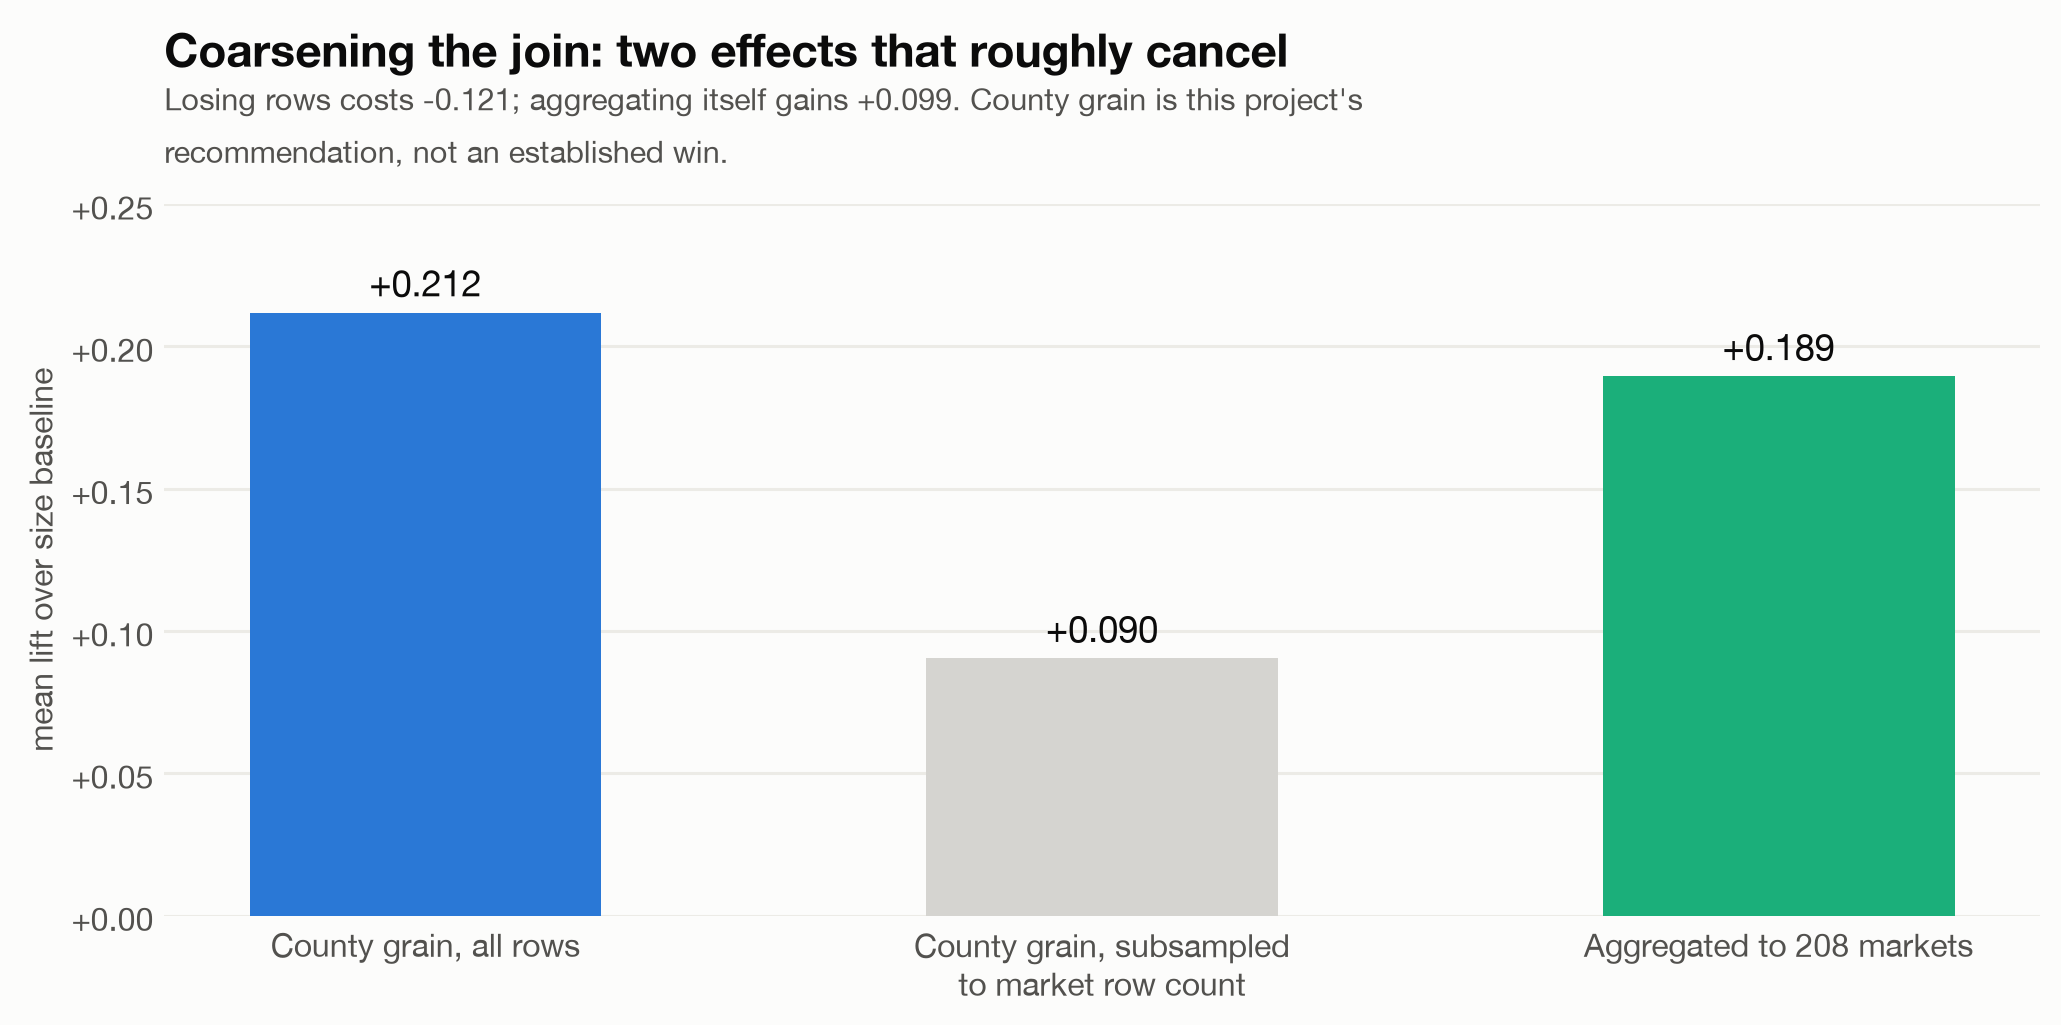

In [7]:
arms = [("County grain, all rows", gst["mean_lift_county_full"], BLUE),
        ("County grain, subsampled to market row count", gst["mean_lift_county_subsample"], MUTED),
        (f"Aggregated to {gst['n_markets']} markets", gst["mean_lift_market_aggregate"], AQUA)]
x = np.arange(len(arms))
vals = [a[1] for a in arms]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(x, vals, 0.52, color=[a[2] for a in arms])
ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(a[0], 26) for a in arms])
ax.set_ylim(0, max(vals) * 1.18)
label_bars(ax, x, vals, "{:+.3f}", size=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.set_ylabel("mean lift over size baseline", fontsize=10.5, color=INK2)
style(ax,
      "Coarsening the join: two effects that roughly cancel",
      f"Losing rows costs {gst['row_count_effect']:+.3f}; aggregating itself gains "
      f"{gst['aggregation_effect']:+.3f}. County grain is this project's "
      "recommendation, not an established win.")
plt.show()

**2. On the smallest counties the model cannot win — and that is a data fact, not a
model failure.** The size-only baseline scores a *negative* R² there. ACS publishes
a margin of error with every estimate, and ingesting those alongside the values
splits each outcome's variance into signal and sampling noise. In the smallest
population decile, **30% of the variance is sampling noise** — error no model can
ever explain. In the largest, under 1%.

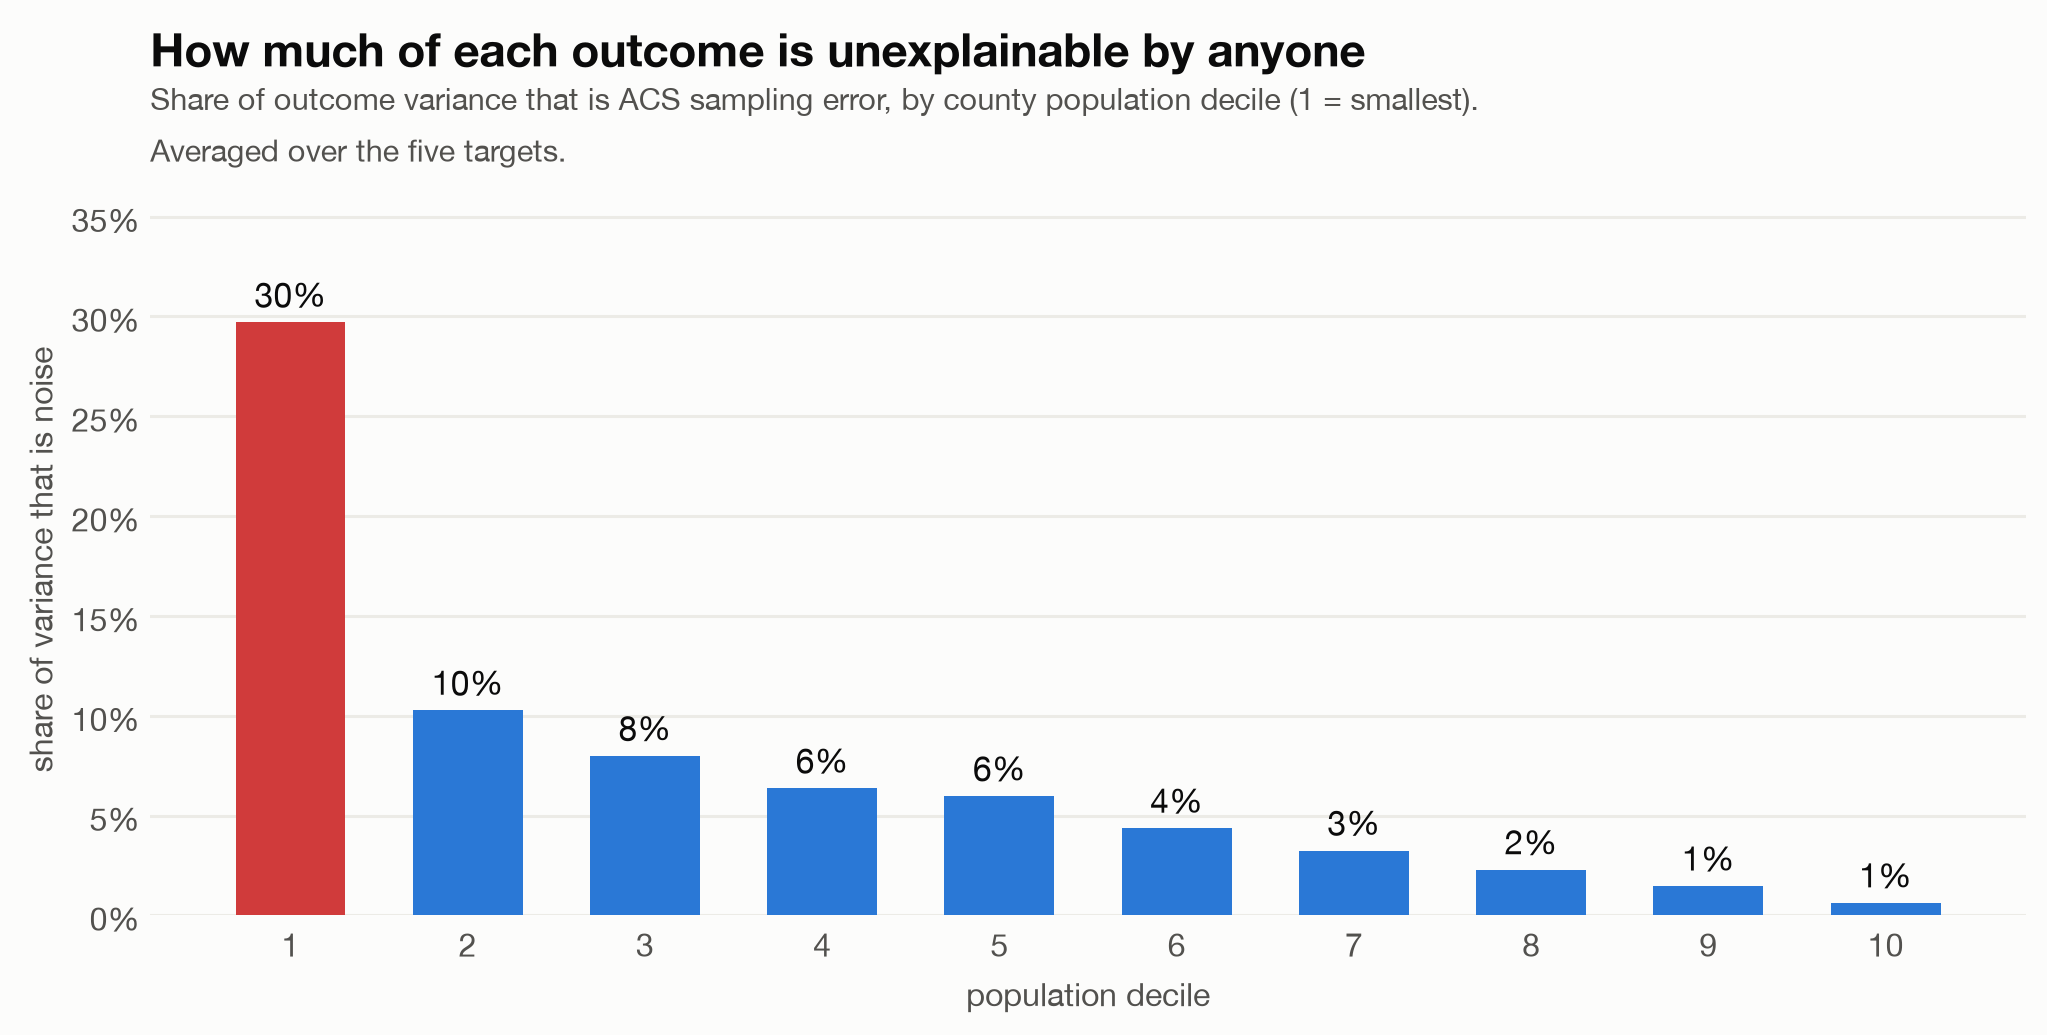

In [8]:
d = (decile.groupby("population_decile")
     .agg(noise_share=("noise_share", "mean"),
          median_population=("median_population", "median"))
     .reset_index())
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(d["population_decile"], d["noise_share"], 0.62,
       color=[CRITICAL if v > 0.15 else BLUE for v in d["noise_share"]])
ax.set_xticks(d["population_decile"])
ax.set_ylim(0, float(d["noise_share"].max()) * 1.2)
label_bars(ax, d["population_decile"], d["noise_share"], "{:.0%}", size=11)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("population decile", fontsize=10.5, color=INK2)
ax.set_ylabel("share of variance that is noise", fontsize=10.5, color=INK2)
style(ax,
      "How much of each outcome is unexplainable by anyone",
      "Share of outcome variance that is ACS sampling error, by county population "
      "decile (1 = smallest). Averaged over the five targets.")
plt.show()

**3. The strongest cross-pillar link in the project is a large-county phenomenon.**
Source B Real Estate LQ against Source E capital-to-wage runs +0.394 nationally,
but **+0.476 in the largest tier and −0.058 in the thinnest**. It does not exist for
the counties with the least data — which anyone serving rural inventory needs stated
before leaning on it.

**Three more, in a line each.** There is **no downstream label** and cannot be one
under this scope. Everything here is **cross-sectional and single-period** —
temporal transfer, which is the one thing a fixed effect genuinely fails at, is
untested. And the **sibling tiers do not line up**: `E_local` is at H3 res-8,
`E_census` does not exist, and nobody owns the reconciliation.

---

## 5. Ruled out, and cleaned up

**Three Source A experiments, none of which changed what ships.** Reading every
section beats reading only economy-titled ones, but **67% of the hits it adds sit
in historical framing** — a defunct-industry detector wearing a current-economy
label. A 384-dimension encoder at 90MB against bge-m3's 2.2GB still loses to the
typed columns. And letting article length decide how much of a page is read loses
in both directions.

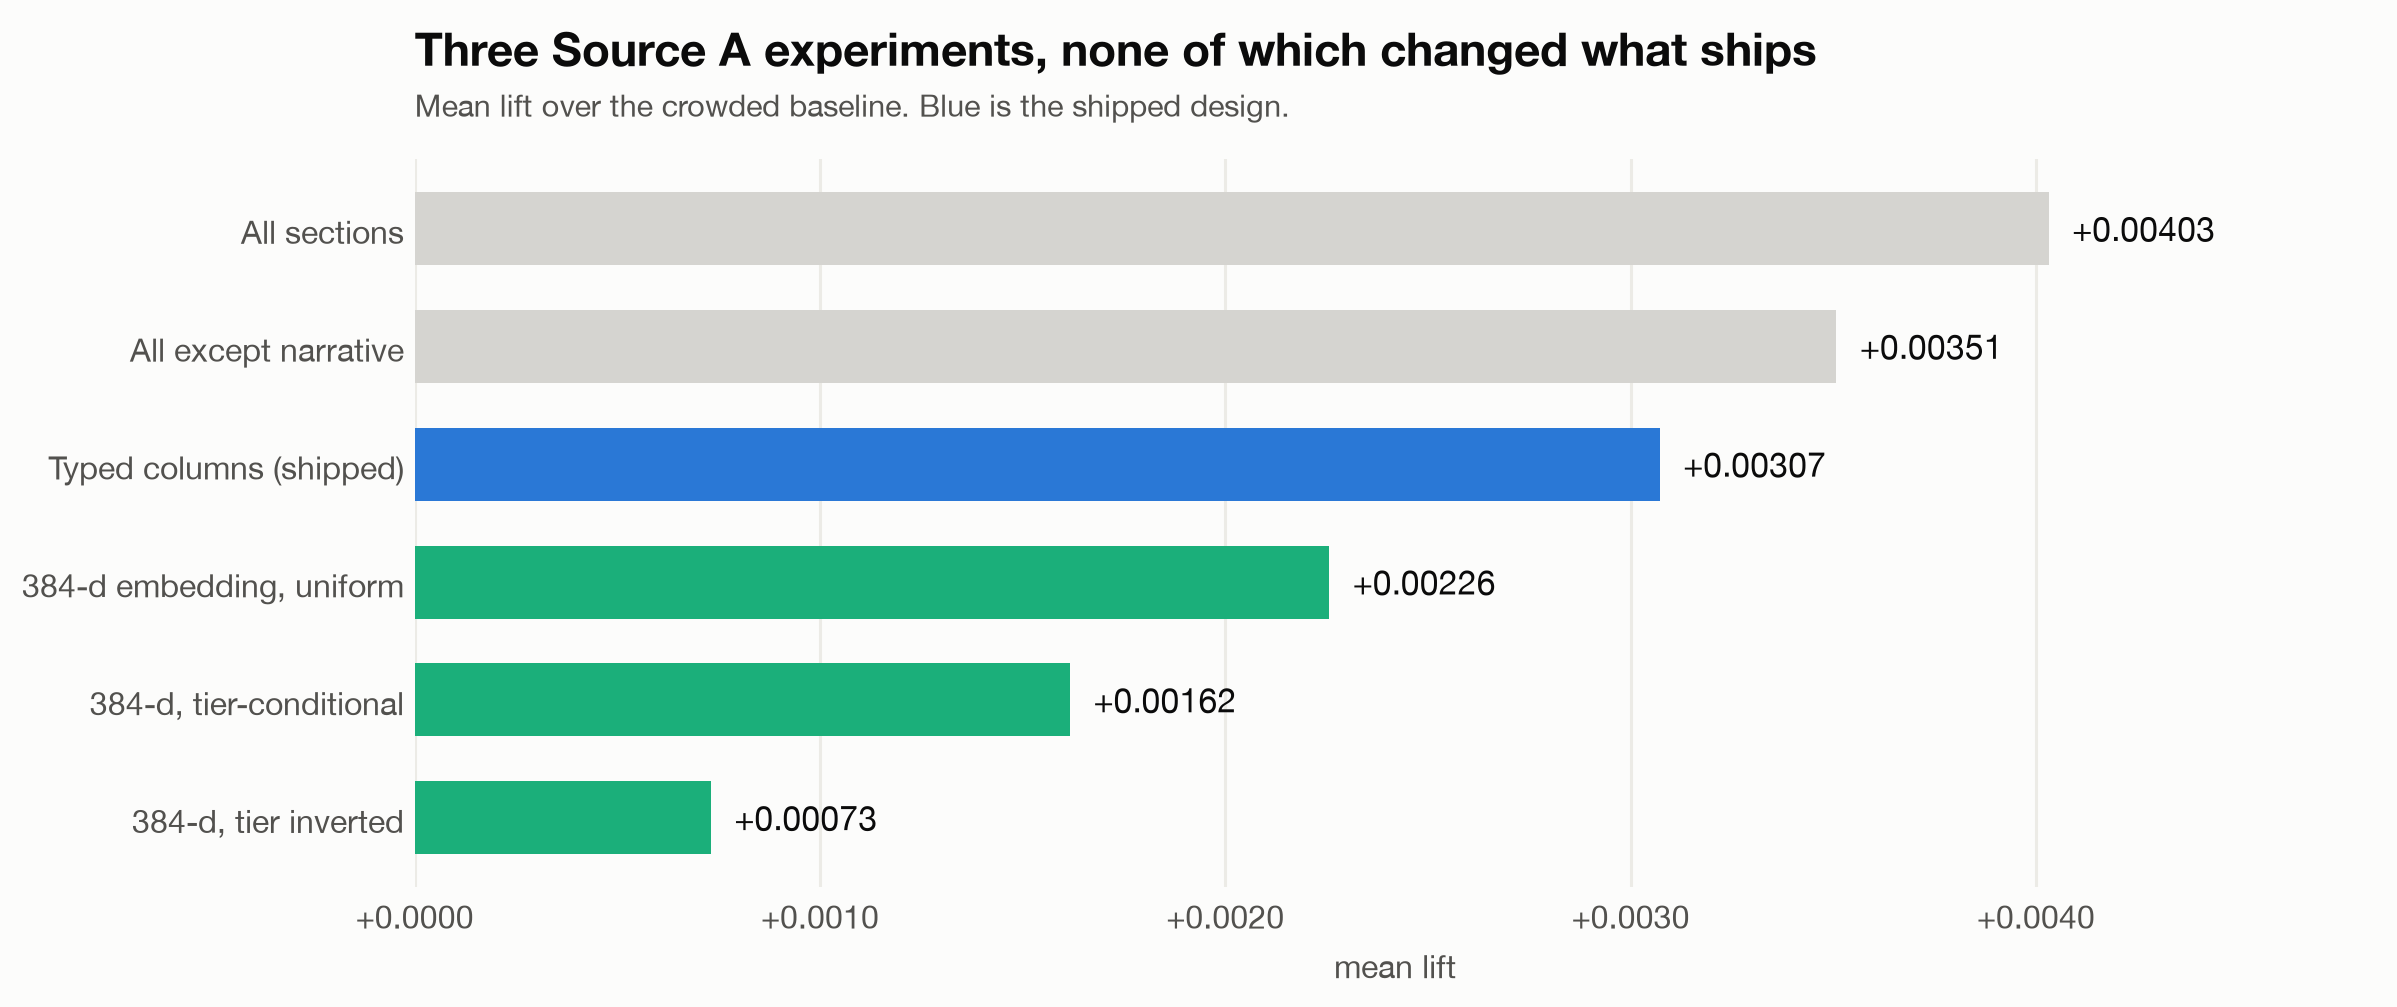

In [9]:
arms = [
    ("Typed columns (shipped)", scope["scopes"]["economy"]["mean_lift"], BLUE),
    ("All sections", scope["scopes"]["all_sections"]["mean_lift"], MUTED),
    ("All except narrative", scope["scopes"]["no_narrative"]["mean_lift"], MUTED),
    ("384-d embedding, uniform", embed["representations"]["uniform"]["mean_lift"], AQUA),
    ("384-d, tier-conditional", embed["representations"]["tier_conditional"]["mean_lift"], AQUA),
    ("384-d, tier inverted", embed["representations"]["tier_conditional_inverse"]["mean_lift"], AQUA),
]
arms = sorted(arms, key=lambda a: a[1])
y = np.arange(len(arms))
vals = [a[1] for a in arms]
fig, ax = plt.subplots(figsize=(11.5, 4.3))
ax.barh(y, vals, height=0.62, color=[a[2] for a in arms])
ax.set_yticks(y)
ax.set_yticklabels([a[0] for a in arms])
ax.set_xlim(0, max(vals) * 1.2)
label_bars(ax, y, vals, "{:+.5f}", size=11, horizontal=True)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.4f}"))
ax.set_xlabel("mean lift", fontsize=10.5, color=INK2)
style(ax,
      "Three Source A experiments, none of which changed what ships",
      "Mean lift over the crowded baseline. Blue is the shipped design.",
      grid_axis="x")
plt.show()

**And the plumbing, which does change what ships.**

- **Size in disguise, removed.** Source D's ten raw freight tonnages and Source E's
  dollar totals moved into the size control at no measured cost; commodity shares
  replaced D's, and 5 of 10 clear a bar none of the raw columns did.
- **Re-derivable at any grain.** Source B now ships raw employment levels and
  Source D its partner-tons distribution, so both can be re-summed rather than
  approximated — which is what makes the grain test above trustworthy. Re-deriving
  D's two concentration indices moved the aggregation gain +0.106 → **+0.099**, a
  correction against this project's own favoured direction.
- **All six pillars carry a frozen schema and an `as_of_date`** (appendix A5).

---

## 6. Where this leaves the project

In [10]:
readiness = pd.DataFrame([
    ("Six sources ingested, validated, schema frozen", "Done",
     "3,143–3,144 counties; six schema docs; vintage per pillar"),
    ("Evidence against a target outside the six pillars", "Done",
     f"{ext['mean_lift_over_size_ablated']:+.3f} mean R² over a size baseline, 5 of 5 positive"),
    ("Each pillar's worth measured, not asserted", "Done",
     "drop-one, restatements ablated, noise floor measured"),
    ("Evidence against the consumer's real target", "Not possible in scope",
     "no downstream label; public proxies only"),
    ("Answer to the DMA fixed-effect objection", "Open",
     "needs the join grain settled"),
    ("Temporal transfer tested", "Not started",
     "cross-sectional only; the strongest untested argument"),
    ("Fusion / serving format", "Deferred by design",
     "packaging, not evidence; grain must settle first"),
], columns=["What a go/no-go needs", "Status", "Where it stands"])
display(readiness.set_index("What a go/no-go needs"))

,Status,Where it stands
What a go/no-go needs,,
"Six sources ingested, validated, schema frozen",Done,"3,143–3,144 counties; six schema docs; vintage..."
Evidence against a target outside the six pillars,Done,"+0.190 mean R² over a size baseline, 5 of 5 po..."
"Each pillar's worth measured, not asserted",Done,"drop-one, restatements ablated, noise floor me..."
Evidence against the consumer's real target,Not possible in scope,no downstream label; public proxies only
Answer to the DMA fixed-effect objection,Open,needs the join grain settled
Temporal transfer tested,Not started,cross-sectional only; the strongest untested a...
Fusion / serving format,Deferred by design,"packaging, not evidence; grain must settle first"


**The remaining path**, in order, measured in weeks of availability:

1. **Settle the join grain** — the single highest-leverage unblock; nothing after it
   is safe to build first.
2. **Benchmark against a geographic fixed effect** — the test that decides whether
   `E_macro` earns a slot in a production model.
3. **Test temporal transfer** — the one argument a fixed effect cannot answer.
4. **Then package** — schema freeze, imputation policy, serving format. Days, not
   weeks: `build_matrix()` already joins all six pillars.

**Not blocked by any of it:** ingestion, validation, schema freeze and the external
benchmark are complete and stand on their own.

---

# Appendix

Written to be read without a narrator.

## A1 — Do public proxies mean anything?

The strongest objection available against section 2, and it deserves a straight
answer rather than a footnote.

**The objection.** `E_macro` is scored against ACS broadband adoption, median
household income, median age, median home value and mean commute. The consuming
team predicts none of those. A feature layer that explains median age tells you
nothing about whether it explains revenue per ad request.

**Conceded immediately.** The objection is correct on its own terms. No result here
is a direct test of usefulness to the consuming team, and none is presented as one.
The label that would make such a test possible is unobtainable: the project was
scoped to public and open-source data only, deliberately and from the start.

**Why the proxies are still worth what they cost.** The alternative was not a better
test — it was the pillar-versus-pillar sweep, which is *circular*. It can establish
that Source B and Source E see the same economy and cannot establish that either
predicts anything at all. Moving to an external target replaces a circular
measurement with a non-circular one. That is a real gain in evidential status even
though the target is a proxy.

**What the proxies license.** That the six pillars carry information counties'
*size* does not already carry — the baseline is population and density and the lift
is measured on held-out states, so it is not memorisation. That the pillars are not
interchangeable, since the drop-one design holds the other five constant. And that
the ordering among them is not arbitrary — E and F clear the noise floor on 5 of 5
targets by an order of magnitude, A does not.

**What they do not license.** Any claim about **magnitude** against an ad-tech
target; +0.190 on ACS outcomes forecasts nothing. Any claim that the **ordering
transfers** — Source A could rank higher against an economically-flavoured target,
which is precisely the section 3 argument for not cutting it unilaterally. And any
answer to the **fixed-effect objection**, which is a different question.

**What would settle it.** One pass of the same drop-one design against a real
downstream target, at the grain the consuming team actually joins on. That needs
either a label or a collaborator inside that team, and is the single most valuable
thing that could be added to this project.

## A2 — Method

**The pre-registered rule**, verbatim from the implementation plan, written before
either script was run and not renegotiated afterwards:

> F ships as a pillar if its marginal contribution — R²(size + all pillars) −
> R²(size + all pillars except F), pooled out-of-fold over the five external ACS
> targets, with restatement columns ablated — is positive on a majority of targets
> and above the shuffled-feature noise floor. Otherwise `E_macro` ships five
> pillars and the go/no-go deck says so plainly.

**Design.** For each pillar, fit two models: one holding county size plus all six
pillars, one holding county size plus five. The difference in out-of-fold R² is that
pillar's marginal contribution. Repeated for all six and for the B+E pair.

**Estimator.** Ridge regression on an imputed design matrix. Missing values are
imputed rather than dropped, because the null patterns are themselves informative
(BLS suppresses ~35% of the LQ matrix) and listwise deletion would silently change
the county population under test.

**Folds.** `GroupKFold` on `state_fips` — spatially blocked, so a model never
predicts a county in a state it trained on. Stricter than random k-fold, and the
right strictness: county features are spatially autocorrelated, and random folds
would let a neighbouring county leak the answer.

**Restatement ablation.** Where a column in one pillar restates a column in another
(Source A's `has_metro_attachment` against Source F's `metro_2023`; Source F's
industry flags against Source B's location quotients), it is removed from both the
full and the reduced model. A pillar that only restated a neighbour then scores zero
by construction, which is the intended behaviour.

**Noise floor.** Each block is shuffled and re-scored — 49 reps in the internal arm,
20 per pillar × target in the external arm. The largest contribution any shuffled
block produced anywhere is +0.0031, and that is the bar drawn in section 2.

**Two arms.** The internal arm scores against 29 in-matrix targets and measures
coherence. The external arm scores against the five ACS targets and is the one the
verdicts rest on. Where they disagree the external arm wins — being unpredictable
from the other five pillars is also exactly what an independent information source
looks like.

## A3 — Limitations, carried over unchanged

- **The targets are public proxies, not the consumer's label**, which is
  structurally unobtainable. Every conclusion is by analogy.
- **20 placebo reps per pillar × target, 49 in the internal arm.** Enough to place a
  floor near zero against contributions an order of magnitude larger. **Not enough
  to resolve a borderline contribution — B's and C's ordering (+0.0067, +0.0054)
  should not be quoted as settled.**
- **Contribution is not importance under a different model class.** Everything here
  is ridge on an imputed design. A gradient-boosted consumer might distribute credit
  differently; only the internal arm carries a GBM cross-check.
- **Cross-sectional and single-period.** Temporal transfer is untested.
- **This does not answer the fixed-effect objection.** It reallocates credit among
  pillars, given that the matrix as a whole beats a size baseline on held-out states.

## A4 — The tier work on Sources A and E

Carried forward from the 6 August brief, which this notebook replaces. The
assignment was to split both pillars into groups and see what the groups changed.

**Verdict: the groups were worth a great deal as a diagnostic and nothing as an
architecture.**

**Source A — four content tiers** on Wikipedia intro length: stub (<100 chars), thin
(100–283), mid (284–461), rich (≥462).

As a diagnostic it paid immediately. Named industry content appears in **1.1% of
thin-tier counties and 25.2% of rich** — a 23× gradient, with fewer than one county
in ten carrying any at all. That killed the dense embedding: averaging 1,024
dimensions over 3,144 articles gives a vector dominated by counties saying nothing
economic. It also picked the feature family worth building — *industry*.

As an architecture it lost three times. Tier-specific slopes cost 9% of the lift,
and four separate per-tier fits scored **−0.01595** against the flat model's
+0.00307 — worse than dropping Source A entirely. Uniform section-widening beat the
tier-conditional rule (+0.00351 vs +0.00307). And through an encoder, in either
direction, uniform won (+0.00226 against +0.00162 and +0.00073).

One reason underneath all three: **partitioning 3,144 counties costs more in pooled
evidence than heterogeneity costs in bias.** Measurable in the embedding run — tier
membership alone explains 0.9–1.0% of vector variance under a uniform rule and
3.7–6.6% under a conditional one. That is the construction rule leaking into the
space, 4–7×, for a variable the baseline already controls for.

The premise was wrong anyway: uniform reading takes stub industry coverage from
6.1% to **34.0%**, thin from 9.7% to 34.9%. Their pages are not empty.

**Source E — four volume tiers** on `num_returns`: T1 (<2.2k), T2 (2.2k–11.7k), T3
(11.7k–100k), T4 (≥100k). Here the groups did more than guide feature choice.

T1 and T4 are each roughly 10% of counties. **T1 holds 0.14% of national investment
income; T4 holds 82.6%.** So an unweighted county feature and the economy it claims
to describe are not the same object — national aggregate ratio 0.156 against an
unweighted county mean of 0.107.

Two earlier conclusions were corrected by the split. **Round 1 had the stability
backwards**: on ranks, Spearman stability *improves* with size (0.861 → 0.941) and
median year-over-year moves *rise* with size (0.298 → 0.393) — so round 1's proposed
fix of weighting by `num_returns` would have upweighted exactly the counties whose
values move most between vintages. And **the dispersion is not sampling noise**:
regressing log dispersion on log median returns gives a slope of +0.026, where pure
sampling error would give −0.5. Small counties' spread is real economic variation.

**Net from the assigned work.** Neither pillar branches on its groups. Source A
ships one uniform schema. Source E ships with an explicit warning that its best
cross-pillar result is conditional on county size. The groups did their job by
changing what gets **shipped** and what gets **disclosed**, not by becoming part of
the model.

## A5 — Pillar vintages

In [11]:
v = vintages.copy()
v["Pillar"] = v["pillar"].map(PILLAR_NAME)
v = v.rename(columns={"as_of_date": "As of", "reference_period": "Reference period",
                      "cadence": "Update cadence"})
display(v[["Pillar", "As of", "Reference period", "Update cadence"]].set_index("Pillar"))

,As of,Reference period,Update cadence
Pillar,,,
A · Place identity,2026-08-03,scrape date (no reference period),continuous
B · Industrial core,2025-12-31,2025 Q4,quarterly
C · Economic velocity,2025-12-31,"unemployment through 2025, real GDP through 2024",monthly (unemployment) / annual (GDP)
D · Trade logistics,2022-12-31,2022,every ~5 years
E · Capital flow,2022-12-31,tax year 2022 (cross-year columns span TY2018-...,annual
F · Structural resilience,2025-12-31,2025 edition (2023 OMB metro delineation),every ~10 years


## A6 — For the consuming team, when it comes to that

**The warning that matters more than which columns ship.** An impression-level
training table joined to `E_macro` carries only 3,143 distinct feature values, so
the effective sample size is the county count — not the row count. Random k-fold
will make this feature layer look good in evaluation and do nothing in production.
**Cluster standard errors by `fips_code`; use grouped, spatially blocked folds.**

Two shorter notes. **Nulls are explicit**: BLS suppresses ~35% of the Source B LQ
matrix, those cells stay null with a `disclosure_*` flag, and IRS publishes no
suppression flag at all — a model must be able to tell "missing" from "zero."
**Size columns are held out deliberately** in `SIZE_COLUMNS`, so a pillar can be
re-derived at a coarser geography; they are not features.

## A7 — Artifact index

Every figure above is computed from a committed artifact. Nothing is hardcoded.

| Section | Reads | Produced by |
|---|---|---|
| 2 · the discount | `external_target_stats.json` (`by_target`) | `scripts/analyze_external_target.py` |
| 2 · pillar worth | `external_target_stats.json` (`drop_one`, `drop_one_noise_floor`) | `scripts/analyze_external_target.py` |
| 3 · Source F | `pillar_block_marginal_stats.json` (`by_block`) | `scripts/analyze_pillar_block_marginal.py` |
| 3 · Source A | `external_target_drop_one_placebo.csv` | `scripts/analyze_external_target.py` |
| 4 · grain | `grain_effect_stats.json` | `scripts/analyze_grain_effect.py` |
| 4 · sampling noise | `outputs/external_target_by_decile.csv` | `scripts/analyze_external_target.py` |
| 5 · ruled out | `source_a_section_scope_stats.json`, `source_a_tiered_embedding_stats.json` | `scripts/analyze_source_a_section_scope.py`, `scripts/analyze_source_a_tiered_embedding.py` |
| A4 · Source E tiers | `source_e_tier_stats.json` | `scripts/analyze_source_e_tiers.py` |
| A5 · vintages | `outputs/pillar_vintages.csv` | `scripts/pillar_vintage.py` |

Long-form evidence:
`analysis-output/cross-source/pillar-marginal-findings.md`,
`analysis-output/cross-source/external-target-findings.md`,
`analysis-output/E_macro_key_findings.ipynb`,
`docs/pillar_status.md`, `docs/PROJECT_GOAL.md`.